# 06 — LSTM Model (Weekly)

Weekly LSTM on silver log-returns. Uses the same W-FRI feature frame and train/val/test split
as ARIMA, RF, and XGBoost — directly comparable.

**Rebalancing assumption.** Features are observed at Friday close $t-1$; the model predicts
the log-return from Friday $t-1$ to Friday $t$. The `SEQ_LEN` window provides the temporal
lag implicitly: the input sequence ends at Friday $t-1$, so no week-$t$ value ever enters.

**Training design.** With only ~330 training sequences after SEQ_LEN warmup, capacity is kept
low: a single LSTM layer, tuned dropout, and early stopping on val loss. No walk-forward
retraining — with so few sequences each refit adds negligible new signal while destabilising
the model. Hyperparameters (`SEQ_LEN`, `HIDDEN`, `DROPOUT`) are tuned once on the EXOG variant
and reused across all variants.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 1 | Hyperparameters | `SEQ_LEN` / `HIDDEN` / `DROPOUT` / batch / epochs + device (MPS→CUDA→CPU), `SEED=42`. |
| 2 | Load + aggregate | Read the shared weekly W-FRI frame; build the silver target, feature groups, and train/val/test split. |
| 3 | Architecture & helpers | Single-layer LSTM with an explicit dropout before the head; sequence builder + train/eval helpers. |
| 4 | Hyperparameter tuning | Mini-grid `SEQ_LEN × HIDDEN × DROPOUT = 2×2×3` tuned **once** on `LSTM-EXOG` by val loss + early stopping; the best config is reused across all variants. |
| 5 | Train variants | Train each variant once on train+val and predict the full test set in one pass — the 17-rung ladder below. |
| 5b | Training diagnostics | Per-variant train-vs-val loss curves. |
| 6 | Results | One table — RMSE / MAE / OOS R² / DA / WDA for Naive, Drift, and every variant. Save `metrics_lstm_weekly.csv`. |
| 7 | Sub-period robustness | Pick the best variant by RMSE (primary) and WDA (secondary); break down by `PERIODS`; save period + preds CSVs. |
| 8 | Predicted vs actual | Full window, two panels (WDA-best, RMSE-best), drift overlaid. |
| 9 | Significance tests | Load-bearing DM vs-Drift floor (OOS R² + DM, squared & absolute error). 9b: Pesaran–Timmermann directional lens. 9c: ex-2025 robustness. |
| 10 | 2026 zoom | WDA-best and RMSE-best vs the drift floor on the 2026 YTD slice. |

**Variant ladder** — same 17 rungs as RF / XGBoost (§4 of those notebooks), plus `LSTM-Y`
(silver-only, the recurrent analogue of ARIMA's own-history model):

| Variant | Features |
|---|---|
| `LSTM-Y` | Silver return only (weak-form test) |
| `LSTM-TECH` | Silver + directional tech indicators (no cross-assets) |
| `LSTM-EXOG` | Silver + 6 cross-asset returns (baseline) |
| `LSTM-EXOG-GS` | EXOG + gold/silver ratio z-score |
| `LSTM-EXOG-NONLIN` | EXOG + squared returns |
| `LSTM-EXOG-TECH` | EXOG + tech indicators |
| `LSTM-EXOG-MACRO` | EXOG + monthly macro lags |
| `LSTM-EXOG-FRED` | EXOG + daily FRED changes |
| `LSTM-EXOG-COT` | EXOG + COT positioning |
| `LSTM-EXOG-FRED-COT` | EXOG + FRED + COT |
| `LSTM-EXOG-REDDIT` | EXOG + Reddit sentiment |
| `LSTM-EXOG-NEWS` | EXOG + news sentiment |
| `LSTM-EXOG-SENTIMENT` | EXOG + Reddit + news |
| `LSTM-EXOG-GS-SENTIMENT` | EXOG + GS + sentiment |
| `LSTM-EXOG-NONLIN-SENTIMENT` | EXOG + NonLin + sentiment |
| `LSTM-EXOG-TECH-SENTIMENT` | EXOG + tech + sentiment |
| `LSTM-EXOG-ALL` | GS + NonLin + Tech + FRED + COT + sentiment (no MACRO) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Hyperparameters

Defaults set in the next cell. **`SEQ_LEN`, `HIDDEN`, `DROPOUT` are overwritten by the §4 grid
search** (tuned once on the EXOG variant's val loss, then reused across all variants — see §4);
the rest stay fixed throughout.

| Param | Default | Tuned §4 | Role |
|---|---|:---:|---|
| `SEQ_LEN` | 20 | ✓ | Lookback length — number of past weeks fed to the LSTM per prediction. Also supplies the 1-week feature lag implicitly: the window ends Friday $t-1$ and predicts $y_t$, so no week-$t$ value ever enters the input. |
| `HORIZON` | 1 | — | Forecast horizon: one week ahead (Friday $t-1$ → Friday $t$). |
| `HIDDEN` | 32 | ✓ | LSTM hidden-state width — model capacity. |
| `N_LAYERS` | 1 | — | Stacked LSTM layers. One, given only ~355 training sequences (deeper overfits). |
| `DROPOUT` | 0.2 | ✓ | Dropout applied to the final hidden state before the linear head. `nn.LSTM`'s built-in dropout is a no-op with a single layer, so an explicit `nn.Dropout` is used instead. |
| `EPOCHS` | 150 | — | Maximum training epochs — a ceiling; early stopping almost always triggers first. |
| `LR` | 1e-3 | — | Adam learning rate. |
| `PATIENCE` | 15 | — | Early-stopping patience — epochs of no val-loss improvement before training halts. |
| `BATCH` | 16 | — | Mini-batch size. Small because the sample is small (~355 train sequences). |

In [2]:
SEQ_LEN  = 20    # lookback: 20 weeks (~5 months)
HORIZON  = 1     # 1 week ahead
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 16    # smaller batch — fewer sequences

TARGET = 'silver_return'

## 2. Load & aggregate to weekly

In [3]:
# Weekly feature frame (built once by 02_features.ipynb §8 — single source of truth).
weekly = pd.read_csv('../../data/processed/features_weekly.csv', index_col=0, parse_dates=True)

EXOG_RETURNS = ['gold_return', 'usd_return', 'copper_return',
                'sp500_return', 'vix_return', 'oil_return']
EXOG_LEVELS  = ['gs_ratio_z']   # level features — weekly resample uses .last(), not .sum()
EXOG         = EXOG_RETURNS + EXOG_LEVELS
FEAT_COLS    = [TARGET] + EXOG

# Base weekly matrix per split. Features are UN-lagged — the LSTM's SEQ_LEN window supplies
# the 1-week lag (the sequence ending Friday t-1 predicts y_t). Split on the frame's `split`
# column so train/val/test stay separate for sequence building.
def _split(name):
    return weekly[weekly['split'] == name][[TARGET] + EXOG].dropna().copy()
train, val, test = _split('train'), _split('val'), _split('test')

# Sentiment: weekly means from the frame, ffill then 0-fill (the LSTM standardises features).
for df in (train, val, test):
    for col in ['reddit_sentiment', 'news_sentiment']:
        df[col] = weekly[col].reindex(df.index).ffill().fillna(0)

print(f'Train weeks: {len(train)}  Val weeks: {len(val)}  Test weeks: {len(test)}')
print(f'Features: {train.columns.tolist()}')

Train weeks: 365  Val weeks: 52  Test weeks: 174
Features: ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'gs_ratio_z', 'reddit_sentiment', 'news_sentiment']


In [4]:
# Directional technical indicators — read RAW from the frame (02_features §8 / 02c); the SEQ_LEN
# window supplies the 1-week lag, exactly like the EXOG returns (no pre-shift). 0-filled for
# warmup NaNs. The feature-group registry loaded here is reused by the macro / FRED / COT cells.
import json as _json
with open('../../data/processed/feature_groups.json') as _f:
    GROUPS = _json.load(_f)
TECH_COLS = GROUPS['TECH']
for df in (train, val, test):
    for col in TECH_COLS:
        df[col] = weekly[col].reindex(df.index).fillna(0)
print(f'Technical indicators joined (directional, raw — window lags): {TECH_COLS}')

Technical indicators joined (directional, raw — window lags): ['macd_line', 'macd_hist', 'rsi_14w', 'mom_5w', 'roc_13w', 'roc_26w', 'roc_52w', 'price_ma13w', 'donchian_52w', 'bb_pct_b']


In [5]:
# ── Nonlinear (squared) features ────────────────────────────────────────────
# Squared returns capture magnitude / volatility regardless of sign, motivated
# by ARCH-style volatility clustering. No explicit lag needed: the LSTM's
# SEQ_LEN window provides the temporal lag implicitly — the sequence ending
# Friday t-1 already includes the squared returns at t-SEQ_LEN..t-1 when
# predicting y_t (no week-t value enters the input).
SQ_COLS = []
for col in [TARGET] + EXOG_RETURNS:
    sq_name = f'{col}_sq'
    for df in [train, val, test]:
        df[sq_name] = df[col] ** 2
    SQ_COLS.append(sq_name)

print(f'Nonlinear (squared) features added: {SQ_COLS}')

Nonlinear (squared) features added: ['silver_return_sq', 'gold_return_sq', 'usd_return_sq', 'copper_return_sq', 'sp500_return_sq', 'vix_return_sq', 'oil_return_sq']


In [6]:
# ── Monthly macro: leak-corrected weekly lags from the frame (MACRO group, already lagged) ──
# Level series → back-filled for the 2015 warmup (a 0 would be a wild outlier after
# standardisation). The 2023–2026 test period is fully covered.
MACRO_COLS = GROUPS['MACRO']
for df in (train, val, test):
    for col in MACRO_COLS:
        df[col] = weekly[col].reindex(df.index).ffill().bfill()
print(f'Monthly macro features joined ({len(MACRO_COLS)}): {MACRO_COLS}')

Monthly macro features joined (12): ['cpi_mlag1', 'cpi_mlag2', 'cpi_mlag3', 'fed_funds_mlag1', 'fed_funds_mlag2', 'fed_funds_mlag3', 'ind_prod_mlag1', 'ind_prod_mlag2', 'ind_prod_mlag3', 'm2_mlag1', 'm2_mlag2', 'm2_mlag3']


In [7]:
# ── Daily-FRED changes + COT positioning from the frame (raw weekly, UN-lagged) ──
# The SEQ_LEN window supplies the 1-week lag, same as the EXOG returns. ffill + 0-fill warmup.
def _join_group(cols):
    for df in (train, val, test):
        for col in cols:
            df[col] = weekly[col].reindex(df.index).ffill().fillna(0)
    return list(cols)
FRED_COLS = _join_group(GROUPS['FRED_DAILY'])
COT_COLS  = _join_group(GROUPS['COT'])
print(f'FRED_daily features joined ({len(FRED_COLS)}): {FRED_COLS}')
print(f'COT features joined ({len(COT_COLS)}): {COT_COLS}')

FRED_daily features joined (3): ['real_rates_chg', 'breakeven_chg', 'jobless_chg']
COT features joined (2): ['cot_mm_net_pct', 'cot_comm_net_pct']


## 3. Architecture & helpers

Three components used by every variant:

- **`LSTMForecaster`** — single-layer LSTM followed by dropout and a linear head. Single layer
  is deliberate: ~330 training sequences is too few for stacked layers without overfitting.
  Dropout is applied to the final hidden state (not between layers, since there is only one).

- **`make_sequences`** — sliding-window builder. Converts a scaled numpy array into
  `(SEQ_LEN × n_features)` input tensors and scalar targets. The window ending at $t-1$
  predicts $y_t$, so no current-week values enter the input.

- **`run_variant`** — trains one variant end-to-end: scales features, builds sequences,
  runs the training loop with early stopping, checkpoints the best model, then predicts
  the full test set and un-scales back to raw returns.


In [8]:
class LSTMForecaster(nn.Module):
    """Single-layer LSTM -> Dropout -> Linear(1) regression head.

    Architecture kept minimal for the ~330-sequence sample: one recurrent layer
    (stacking would overfit), dropout on the final hidden state, scalar output.
    nn.LSTM's built-in dropout is passed 0.0 because it only acts between stacked
    layers -- the tuned dropout is applied via an explicit nn.Dropout instead.
    """
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))   # last hidden state -> scalar


def make_sequences(data, seq_len, target_col, horizon=1):
    """Sliding-window sequence builder.

    Args:
        data:       scaled numpy array (n_timesteps x n_features)
        seq_len:    lookback length -- rows per input window
        target_col: column index of the return target in `data`
        horizon:    number of steps ahead to predict (summed; 1 for weekly)
    Returns:
        X: (n_samples, seq_len, n_features)
        y: (n_samples,) -- raw target values (still scaled)
    """
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


LOSS_HISTORIES = {}   # variant -> {train, val, best_epoch}; populated for the §5b loss curves


def run_variant(name, feature_cols):
    """Train one variant end-to-end and return metrics + predictions.

    Steps:
      1. Scale features (StandardScaler fit on train only -- no leak).
      2. Build sequences: non-overlapping weekly windows for train/val/test.
         Test is warmed from the val tail so all test weeks are predicted.
      3. Train with Adam + ReduceLROnPlateau + early stopping; checkpoint best val loss.
      4. Reload best checkpoint, predict test set, un-scale back to raw returns.

    Returns:
        metrics dict, preds array, actuals array, dates index
    """
    print(f'\n{"=" * 50}\nVariant: {name}\n{"=" * 50}')
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    # Gradient descent is sensitive to feature scale: large-magnitude inputs produce
    # large gradients that swamp small ones. StandardScaler (mean=0, std=1) levels
    # the playing field. Fit on train only so val/test statistics don't leak in.
    scaler        = StandardScaler().fit(train[cols].fillna(0))
    train_scaled  = scaler.transform(train[cols].fillna(0))
    val_scaled    = scaler.transform(val[cols].fillna(0))
    test_scaled   = scaler.transform(test[cols].fillna(0))

    # X: (n_weeks - SEQ_LEN, SEQ_LEN, n_features) -- stack of overlapping windows
    # y: (n_weeks - SEQ_LEN,) -- one target scalar per window
    # The SEQ_LEN warmup cost drops the first SEQ_LEN weeks (no history to look back through).
    X_train, y_train = make_sequences(train_scaled, SEQ_LEN, target_idx, HORIZON)
    X_val,   y_val   = make_sequences(val_scaled,   SEQ_LEN, target_idx, HORIZON)

    # Prepend the last SEQ_LEN val rows to test so the first test week has a full
    # lookback window. Val and test are contiguous W-FRI so these rows are strictly
    # past -- no look-ahead. Without this, the first SEQ_LEN test weeks would be lost.
    test_scaled_warmed   = np.concatenate([val_scaled[-SEQ_LEN:], test_scaled]) # Asier: find out what this warming means
    X_test, y_test       = make_sequences(test_scaled_warmed, SEQ_LEN, target_idx, HORIZON)
    dates                = test.index[:len(test) - HORIZON + 1]

    print(f'  Train seqs: {len(X_train)}  Val seqs: {len(X_val)}  Test seqs: {len(X_test)}')

    # DataLoader handles batching and shuffling. Training shuffles to break the
    # temporal order within a batch (each sequence is already a self-contained window,
    # so shuffling sequences is fine and helps generalisation). Val/test stay ordered.
    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_train, y_train)
    val_loader   = to_loader(X_val,   y_val,   shuffle=False)

    checkpoint_path = f'../../data/processed/lstm_{name.lower().replace("+","_").replace(" ","_")}_weekly_best.pt'
    model     = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()
    # Halve the learning rate if val loss hasn't improved for 3 epochs. Lets the
    # optimiser take finer steps once it's close to a minimum.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_val_loss, patience_count, best_epoch = np.inf, 0, 0
    hist_train, hist_val = [], []
    for epoch in range(1, EPOCHS + 1):
        # Training mode: enables dropout (randomly zeros hidden units to prevent
        # co-adaptation, i.e. the model learns redundant representations).
        model.train()
        epoch_train_losses = []
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)

            optimizer.zero_grad()                        # clear gradients from the previous batch --
                                                         # PyTorch accumulates by default, so must reset
            loss = criterion(model(x_batch), y_batch)   # forward pass: predict, then compute MSE loss
            loss.backward()                              # backprop: compute dLoss/dWeight for every parameter
                                                         # via the chain rule through all layers
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # cap gradient norm --
                                                         # RNNs are prone to exploding gradients through
                                                         # long sequences (many chain-rule multiplications)
            optimizer.step()                             # gradient descent step: w = w - lr * grad
            epoch_train_losses.append(loss.item())

        # Eval mode: disables dropout so predictions are deterministic.
        # no_grad: skips building the computation graph (not needed for inference),
        # saving memory and speeding up the validation pass.
        model.eval()
        with torch.no_grad():
            val_loss = np.mean([criterion(model(x_batch.to(DEVICE)), y_batch.to(DEVICE)).item()
                                for x_batch, y_batch in val_loader])
        scheduler.step(val_loss)
        hist_train.append(float(np.mean(epoch_train_losses)))
        hist_val.append(float(val_loss))
        if epoch % 25 == 0:
            print(f'  Epoch {epoch:3d}  val={val_loss:.6f}')

        # Checkpoint the weights whenever val loss improves; revert to this
        # at the end so we return the best generalising model, not the last one.
        if val_loss < best_val_loss:
            best_val_loss, patience_count, best_epoch = val_loss, 0, epoch
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break
    LOSS_HISTORIES[name] = {'train': hist_train, 'val': hist_val, 'best_epoch': best_epoch}

    # Reload best checkpoint and predict the test set.
    model.load_state_dict(torch.load(checkpoint_path))
    model.eval()
    preds_list, actuals_list = [], []
    with torch.no_grad():
        test_loader = to_loader(X_test, y_test, shuffle=False)
        for x_batch, y_batch in test_loader:
            preds_list.extend(model(x_batch.to(DEVICE)).cpu().numpy().flatten())
            actuals_list.extend(y_batch.numpy().flatten())

    # Un-scale: model predicted in standardised units; convert back to raw weekly returns.
    target_mean = scaler.mean_[target_idx]
    target_std  = scaler.scale_[target_idx]
    preds   = np.array(preds_list)   * target_std + HORIZON * target_mean
    actuals = np.array(actuals_list) * target_std + HORIZON * target_mean

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test sequences: {len(preds)} weekly predictions')

    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates


## 4. Hyperparameter tuning

Mini-grid over `SEQ_LEN`, `HIDDEN`, `DROPOUT` evaluated on the **`EXOG`** variant
(silver + 6 cross-asset returns) using val loss with early stopping. The best
configuration is reused across all downstream variants.

Tuning on EXOG rather than the kitchen sink is deliberate: with only ~330 training
sequences, a high-dimensional input (30+ features) adds noise to the HP search and
risks selecting overly conservative regularisation. EXOG gives a cleaner, lower-variance
signal about what `SEQ_LEN` and `HIDDEN` suit the data's temporal structure.
(Kitchen-sink tuning was tested and yielded worse val loss than EXOG-tuned params.)


In [9]:
from itertools import product

SEQ_GRID     = [10, 20]
HIDDEN_GRID  = [16, 32]
DROPOUT_GRID = [0.1, 0.2, 0.3]

# Tune on EXOG (silver + 6 cross-asset returns): gives a cleaner, lower-variance
# HP signal than the kitchen sink on this small sample (~330 sequences). With 30+
# features the search risks selecting overly conservative regularisation.
# (Kitchen-sink tuning was tested and yielded worse val loss than these params.)
tune_cols = [TARGET] + [c for c in EXOG_RETURNS if c in train.columns]


def eval_config(seq_len, hidden, dropout):
    """Train one LSTM config on train, return best val loss (with early stopping)."""
    scaler     = StandardScaler().fit(train[tune_cols].fillna(0))
    train_s    = scaler.transform(train[tune_cols].fillna(0))
    val_s      = scaler.transform(val[tune_cols].fillna(0))
    target_idx = tune_cols.index(TARGET)

    X_train, y_train = make_sequences(train_s, seq_len, target_idx, HORIZON)
    X_val,   y_val   = make_sequences(val_s,   seq_len, target_idx, HORIZON)
    if len(X_train) == 0 or len(X_val) == 0:
        return np.inf

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train).unsqueeze(1)),
                              batch_size=BATCH, shuffle=True)
    val_loader   = DataLoader(TensorDataset(torch.tensor(X_val),   torch.tensor(y_val).unsqueeze(1)),
                              batch_size=BATCH, shuffle=False)

    model     = LSTMForecaster(len(tune_cols), hidden, N_LAYERS, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.MSELoss()

    best_val_loss, patience_count = np.inf, 0
    for _ in range(EPOCHS):
        model.train()
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        model.eval()
        with torch.no_grad():
            val_loss = np.mean([criterion(model(x_batch.to(DEVICE)), y_batch.to(DEVICE)).item()
                                for x_batch, y_batch in val_loader])
        if val_loss < best_val_loss:
            best_val_loss, patience_count = val_loss, 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                break
    return best_val_loss


configs = list(product(SEQ_GRID, HIDDEN_GRID, DROPOUT_GRID))
print(f'Tuning on EXOG variant ({len(tune_cols)} features) — {len(configs)} configs')
print('-' * 60)

search = []
for seq_len, hidden, dropout in configs:
    val_loss = eval_config(seq_len, hidden, dropout)
    print(f'  SEQ_LEN={seq_len:>3}  HIDDEN={hidden:>3}  DROPOUT={dropout}  val_loss={val_loss:.6f}')
    search.append({'seq_len': seq_len, 'hidden': hidden, 'dropout': dropout, 'val_loss': val_loss})

best = min(search, key=lambda r: r['val_loss'])
print(f'\nBest:  SEQ_LEN={best["seq_len"]}  HIDDEN={best["hidden"]}' 
      f'  DROPOUT={best["dropout"]}  val_loss={best["val_loss"]:.6f}')

SEQ_LEN, HIDDEN, DROPOUT = best['seq_len'], best['hidden'], best['dropout']


Tuning on EXOG variant (7 features) — 12 configs
------------------------------------------------------------
  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.1  val_loss=1.383279
  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.2  val_loss=1.407740
  SEQ_LEN= 10  HIDDEN= 16  DROPOUT=0.3  val_loss=1.367774
  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.1  val_loss=1.436756
  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.2  val_loss=1.405364
  SEQ_LEN= 10  HIDDEN= 32  DROPOUT=0.3  val_loss=1.417668
  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.1  val_loss=1.522587
  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.2  val_loss=1.572860
  SEQ_LEN= 20  HIDDEN= 16  DROPOUT=0.3  val_loss=1.517292
  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.1  val_loss=1.509217
  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.2  val_loss=1.505946
  SEQ_LEN= 20  HIDDEN= 32  DROPOUT=0.3  val_loss=1.527625

Best:  SEQ_LEN=10  HIDDEN=16  DROPOUT=0.3  val_loss=1.367774


## 5. Train variants

In [10]:
# Baseline EXOG = silver_return + cross-asset returns (no gs_ratio_z, no NonLin).
# gs_ratio_z and squared returns are treated as separate feature groups tested
# in the ablation variants below.
MARKET_FEATURES = [TARGET] + [c for c in EXOG_RETURNS if c in train.columns]
GS_FEATURES     = [c for c in EXOG_LEVELS  if c in train.columns]
SENT_FEATURES   = ['reddit_sentiment', 'news_sentiment']

# Canonical ablation ladder — identical rungs/order to 06c (and to the RF/XGB groups
# + the LSTM-only Y rung). MACRO/FRED/COT are inline and EXOG-ALL is the full kitchen
# sink. (The old RNG-append ordering was dropped now that both LSTMs are re-run fresh.)
variants = {
    'LSTM-Y':                       [TARGET],
    'LSTM-TECH':                    [TARGET] + TECH_COLS,
    'LSTM-EXOG':                    MARKET_FEATURES,
    'LSTM-EXOG-GS':                 MARKET_FEATURES + GS_FEATURES,
    'LSTM-EXOG-NONLIN':             MARKET_FEATURES + SQ_COLS,
    'LSTM-EXOG-TECH':               MARKET_FEATURES + TECH_COLS,
    'LSTM-EXOG-MACRO':              MARKET_FEATURES + MACRO_COLS,
    'LSTM-EXOG-FRED':               MARKET_FEATURES + FRED_COLS,
    'LSTM-EXOG-COT':                MARKET_FEATURES + COT_COLS,
    'LSTM-EXOG-FRED-COT':           MARKET_FEATURES + FRED_COLS + COT_COLS,
    'LSTM-EXOG-REDDIT':             MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-EXOG-NEWS':               MARKET_FEATURES + ['news_sentiment'],
    'LSTM-EXOG-SENTIMENT':          MARKET_FEATURES + SENT_FEATURES,
    'LSTM-EXOG-GS-SENTIMENT':       MARKET_FEATURES + GS_FEATURES + SENT_FEATURES,
    'LSTM-EXOG-NONLIN-SENTIMENT':   MARKET_FEATURES + SQ_COLS + SENT_FEATURES,
    'LSTM-EXOG-TECH-SENTIMENT':     MARKET_FEATURES + TECH_COLS + SENT_FEATURES,
    # Kitchen sink: GS + NonLin + Tech + FRED + COT + Sentiment (no MACRO, mirroring RF/XGB)
    'LSTM-EXOG-ALL':                MARKET_FEATURES + GS_FEATURES + SQ_COLS + TECH_COLS + FRED_COLS + COT_COLS + SENT_FEATURES,
}

results     = {}
all_preds   = {}
actuals_arr = None
dates_arr   = None

for name, cols in variants.items():
    m, preds, acts, dates = run_variant(name, cols)
    results[name]   = m
    all_preds[name] = preds
    actuals_arr     = acts
    dates_arr       = dates


Variant: LSTM-Y
  Train seqs: 355  Val seqs: 42  Test seqs: 174
  Early stopping at epoch 20
  RMSE=0.051800  MAE=0.037096  DA=0.552  WDA=0.586
  Test sequences: 174 weekly predictions

Variant: LSTM-TECH
  Train seqs: 355  Val seqs: 42  Test seqs: 174
  Early stopping at epoch 23
  RMSE=0.052176  MAE=0.037617  DA=0.477  WDA=0.478
  Test sequences: 174 weekly predictions

Variant: LSTM-EXOG
  Train seqs: 355  Val seqs: 42  Test seqs: 174
  Early stopping at epoch 19
  RMSE=0.052159  MAE=0.037549  DA=0.443  WDA=0.462
  Test sequences: 174 weekly predictions

Variant: LSTM-EXOG-GS
  Train seqs: 355  Val seqs: 42  Test seqs: 174
  Epoch  25  val=1.425726
  Early stopping at epoch 30
  RMSE=0.051899  MAE=0.037122  DA=0.609  WDA=0.628
  Test sequences: 174 weekly predictions

Variant: LSTM-EXOG-NONLIN
  Train seqs: 355  Val seqs: 42  Test seqs: 174
  Early stopping at epoch 17
  RMSE=0.052103  MAE=0.037280  DA=0.552  WDA=0.542
  Test sequences: 174 weekly predictions

Variant: LSTM-EXOG-TE

## 5b. Training diagnostics — loss curves

Per-epoch **train vs validation MSE** (standardised returns), captured during §5 at no cost.
Variants are **ranked by their best (minimum) validation loss**; the lowest is highlighted in the
right panel and shown train-vs-val on the left (dashed line = early-stopping `best_epoch`).

> Note the whole band sits **above ~1.0** (= predicting the train mean), so even the "best"
> variant has *negative* out-of-sample R² — "converges lower" means *less bad*, not skill. It
> still has to beat the Drift on the **test** set (§6/§9), which it doesn't.

rank  variant                        min val  @epoch  final val
----------------------------------------------------------------
   1  LSTM-EXOG-FRED-COT              1.3539       4     1.3682
   2  LSTM-EXOG-GS-SENTIMENT          1.3662       1     1.4009
   3  LSTM-EXOG-MACRO                 1.3677       6     1.3740
   4  LSTM-EXOG-ALL                   1.3715       3     1.4071
   5  LSTM-EXOG-NONLIN-SENTIMENT      1.3868       4     1.3982
   6  LSTM-EXOG-SENTIMENT             1.3911       1     1.4082
   7  LSTM-EXOG-NEWS                  1.3943       4     1.4102
   8  LSTM-EXOG                       1.3983       4     1.4105
   9  LSTM-EXOG-COT                   1.4049       4     1.4282
  10  LSTM-EXOG-GS                    1.4065      15     1.4290
  11  LSTM-Y                          1.4065       5     1.4081
  12  LSTM-EXOG-TECH-SENTIMENT        1.4199       3     1.4424
  13  LSTM-TECH                       1.4226       8     1.4410
  14  LSTM-EXOG-NONLIN                1

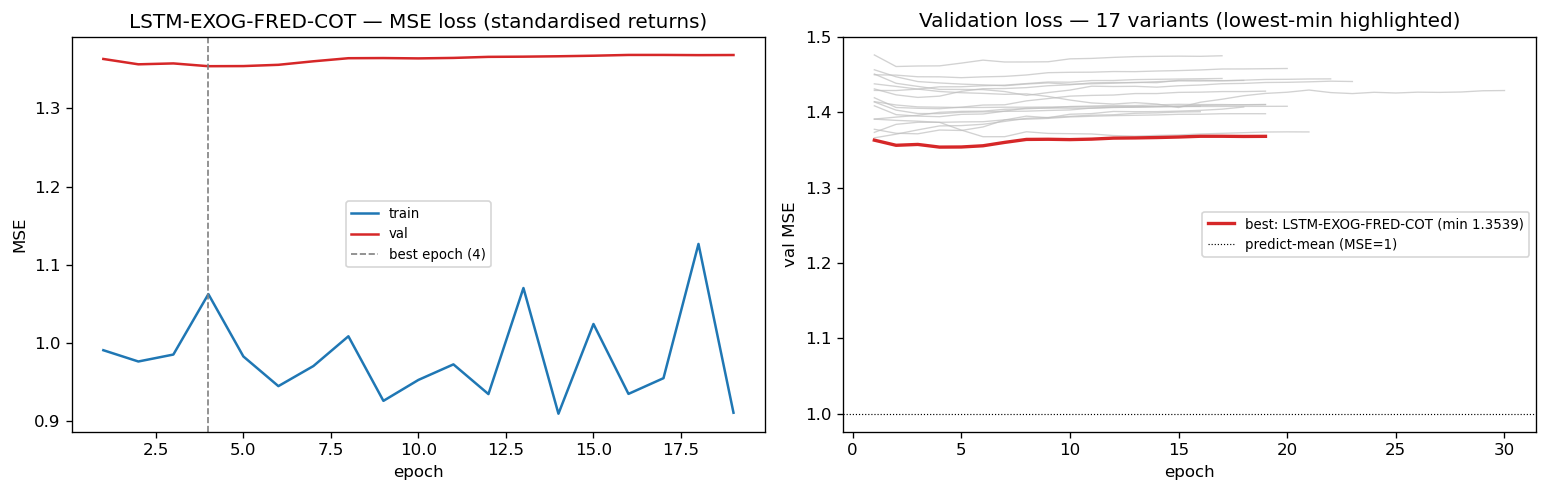

In [11]:
# Loss curves from the §5 training runs (LOSS_HISTORIES populated by run_variant).
assert LOSS_HISTORIES, 'Run §5 (Train variants) first to populate LOSS_HISTORIES.'

# Rank variants by the best (minimum) validation loss they reach -- this NAMES the
# variant whose curve looks like it "converges" lowest in the overlay.
rank = sorted(LOSS_HISTORIES, key=lambda n: min(LOSS_HISTORIES[n]['val']))
print(f'{"rank":>4}  {"variant":<28}  {"min val":>8}  {"@epoch":>6}  {"final val":>9}')
print('-' * 64)
for i, n in enumerate(rank, 1):
    v = LOSS_HISTORIES[n]['val']
    print(f'{i:>4}  {n:<28}  {min(v):>8.4f}  {int(np.argmin(v)) + 1:>6}  {v[-1]:>9.4f}')
best = rank[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) the lowest-min-val variant: train vs val (does its 'convergence' hold up?)
h  = LOSS_HISTORIES[best]
ep = range(1, len(h['train']) + 1)
axes[0].plot(ep, h['train'], color='#1f77b4', label='train')
axes[0].plot(ep, h['val'],   color='#d62728', label='val')
axes[0].axvline(h['best_epoch'], color='grey', ls='--', lw=1, label=f"best epoch ({h['best_epoch']})")
axes[0].set(title=f'{best} — MSE loss (standardised returns)', xlabel='epoch', ylabel='MSE')
axes[0].legend(fontsize=8)

# (b) all variants' val loss; lowest-min highlighted, rest greyed (de-clutters the 17-line overlay)
for n in rank:
    if n == best:
        continue
    v = LOSS_HISTORIES[n]['val']
    axes[1].plot(range(1, len(v) + 1), v, color='0.75', lw=0.8, alpha=0.7, zorder=1)
vb = LOSS_HISTORIES[best]['val']
axes[1].plot(range(1, len(vb) + 1), vb, color='#d62728', lw=2.0, zorder=3,
             label=f'best: {best} (min {min(vb):.4f})')
axes[1].axhline(1.0, color='black', lw=0.7, ls=':', zorder=2, label='predict-mean (MSE=1)')
axes[1].set(title=f'Validation loss — {len(rank)} variants (lowest-min highlighted)',
            xlabel='epoch', ylabel='val MSE')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Results

**Metrics** — RMSE / MAE (magnitude), OOS R² (effect size vs Drift, shown as `r2_os` below), DA / WDA (direction). Formulas, caveats, and load-bearing status: `01_arima` §5 or [`tests.md`](tests.md).

In [12]:
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import oos_r2, period_metrics, diebold_mariano, PERIODS

# Naive baseline: predict y_t = y_{t-1}.
naive_pred = np.concatenate([[np.nan], actuals_arr[:-1]])
mask       = ~np.isnan(naive_pred)
n_acts     = actuals_arr[mask]
n_preds    = naive_pred[mask]

naive_row = {
    'model':   'Naive (t-1 week)',
    'rmse':    float(np.sqrt(mean_squared_error(n_acts, n_preds))),
    'mae':     float(mean_absolute_error(n_acts, n_preds)),
    'r2_os':   float('nan'),   # different effective length -- not comparable
    'dir_acc': float(np.mean(np.sign(n_acts) == np.sign(n_preds))),
    'wda':     float(np.sum(np.abs(n_acts) * (np.sign(n_acts) == np.sign(n_preds))) / np.sum(np.abs(n_acts))),
}

# Drift / random-walk-with-drift: prevailing (expanding) mean of weekly returns,
# aligned to LSTM test dates (strictly past returns -- no look-ahead). EMH floor:
# ARIMA(0,0,0) by construction; directionally always-up. OOS R^2 = 0 by definition.
_ret       = weekly['silver_return'].dropna().sort_index()
drift_pred = np.array([_ret[_ret.index < d].mean() for d in pd.DatetimeIndex(dates_arr)])
drift_row  = {
    'model':   'Drift (prevailing mean)',
    'rmse':    float(np.sqrt(mean_squared_error(actuals_arr, drift_pred))),
    'mae':     float(mean_absolute_error(actuals_arr, drift_pred)),
    'r2_os':   0.0,
    'dir_acc': float(np.mean(np.sign(actuals_arr) == np.sign(drift_pred))),
    'wda':     float(np.sum(np.abs(actuals_arr) * (np.sign(actuals_arr) == np.sign(drift_pred))) / np.sum(np.abs(actuals_arr))),
}

# All variants -- r2_os: % MSE reduction vs Drift (Campbell-Thompson 2008); >0 beats random walk.
variant_rows = []
for name, row in results.items():
    r = dict(row)
    r['r2_os'] = oos_r2(actuals_arr, all_preds[name], drift_pred) * 100
    variant_rows.append(r)

metrics_df = pd.DataFrame([naive_row, drift_row] + variant_rows)
metrics_df = metrics_df[['model', 'rmse', 'mae', 'r2_os', 'dir_acc', 'wda']]
metrics_df.to_csv('../../data/processed/metrics_lstm_weekly.csv', index=False)

print(f'{"Model":<30}  {"RMSE":>10}  {"MAE":>10}  {"R2_OS":>7}  {"DA":>6}  {"WDA":>6}')
print('-' * 78)
for _, row in metrics_df.iterrows():
    r2 = f'{row["r2_os"]:>+7.2f}' if not pd.isna(row['r2_os']) else '   n/a'
    print(f'{row["model"]:<30}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {r2:>7}  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')

Model                                 RMSE         MAE    R2_OS      DA     WDA
------------------------------------------------------------------------------
Naive (t-1 week)                  0.075941    0.053966      n/a   0.491   0.490
Drift (prevailing mean)           0.051902    0.037135    +0.00   0.557   0.588
LSTM-Y                            0.051800    0.037096    +0.40   0.552   0.586
LSTM-TECH                         0.052176    0.037617    -1.06   0.477   0.478
LSTM-EXOG                         0.052159    0.037549    -0.99   0.443   0.462
LSTM-EXOG-GS                      0.051899    0.037122    +0.01   0.609   0.628
LSTM-EXOG-NONLIN                  0.052103    0.037280    -0.77   0.552   0.542
LSTM-EXOG-TECH                    0.052574    0.037719    -2.61   0.443   0.411
LSTM-EXOG-MACRO                   0.051688    0.036933    +0.82   0.557   0.588
LSTM-EXOG-FRED                    0.052024    0.037252    -0.47   0.529   0.538
LSTM-EXOG-COT                     0.05169

## 7. Sub-period robustness + best-variant selection

In [13]:
def _period_r2_lstm(pred):
    drift_s = pd.Series(drift_pred, index=pd.DatetimeIndex(dates_arr))
    pred_s  = pd.Series(pred,       index=pd.DatetimeIndex(dates_arr))
    yt_s    = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
    r2 = {}
    for _lbl, (_a, _b) in PERIODS.items():
        _y, _p, _d = yt_s.loc[_a:_b].values, pred_s.loc[_a:_b].values, drift_s.loc[_a:_b].values
        if len(_y): r2[_lbl] = oos_r2(_y, _p, _d) * 100
    return r2

def _show_period_lstm(pred, csv=None):
    res = period_metrics(actuals_arr, pred, dates_arr, PERIODS)
    r2  = _period_r2_lstm(pred)
    res['R2_OS'] = [r2.get(lbl, float('nan')) for lbl in res.index]
    display(res[['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']].style
            .format({'n': '{:.0f}', 'RMSE': '{:.4f}', 'MAE': '{:.4f}',
                     'R2_OS': '{:+.2f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
            .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
    if csv:
        res[['n', 'DA', 'WDA']].to_csv(csv)   # legacy schema

def _save_preds_lstm(pred, csv):
    pd.DataFrame({'actual': actuals_arr, 'predicted': pred},
                 index=pd.DatetimeIndex(dates_arr)).rename_axis('Date').to_csv(csv)

best_name      = max(results, key=lambda k: results[k]['wda'])
best_name_rmse = min(results, key=lambda k: results[k]['rmse'])
best_pred      = all_preds[best_name]
best_pred_rmse = all_preds[best_name_rmse]
print(f'Best variant -- WDA: {best_name}  |  RMSE: {best_name_rmse}')

# Drift by period -- the floor (constant-sign, always-up; its DA/WDA = the up-share).
print('\nDrift (prevailing mean) by period -- the floor:')
_show_period_lstm(drift_pred)

print('\nWDA-best by period:')
_show_period_lstm(best_pred, '../../data/processed/period_lstm_weekly.csv')
print('RMSE-best by period:')
_show_period_lstm(best_pred_rmse, '../../data/processed/period_lstm_rmse_weekly.csv')

_save_preds_lstm(best_pred,      '../../data/processed/preds_lstm_best_weekly.csv')
_save_preds_lstm(best_pred_rmse, '../../data/processed/preds_lstm_bestrmse_weekly.csv')
print('\nSaved: period + preds (WDA-best legacy names, RMSE-best alongside).')

# Drift WDA by period (the directional benchmark to beat).
_yt = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
print('\nDrift WDA by period (directional benchmark to beat):')
for _lbl, (_a, _b) in PERIODS.items():
    _s = _yt.loc[_a:_b]
    if len(_s):
        _au = np.sum(np.abs(_s.values) * (_s.values > 0)) / np.sum(np.abs(_s.values))
        print(f'  {_lbl:20s} WDA={_au:.3f}  (n={len(_s)})')


Best variant -- WDA: LSTM-EXOG-COT  |  RMSE: LSTM-EXOG-MACRO

Drift (prevailing mean) by period -- the floor:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.00,0.481,0.492
2024 (bull start),52,0.0380,0.0299,+0.00,0.500,0.570
2025 (bull run),52,0.0498,0.0352,+0.00,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.00,0.556,0.498
── Full test ──,174,0.0519,0.0371,+0.00,0.557,0.588



WDA-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0396,0.0312,+1.98,0.596,0.678
2024 (bull start),52,0.0379,0.0298,+0.29,0.519,0.542
2025 (bull run),52,0.0502,0.0356,-1.42,0.596,0.673
2026 (YTD),18,0.0993,0.0780,+2.06,0.722,0.769
── Full test ──,174,0.0517,0.0369,+0.80,0.586,0.664


RMSE-best by period:


,n,RMSE,MAE,R2_OS,DA,WDA
Period,,,,,,
2023 (choppy),52,0.0400,0.0318,+0.29,0.481,0.492
2024 (bull start),52,0.0379,0.0300,+0.57,0.500,0.570
2025 (bull run),52,0.0493,0.0344,+2.31,0.692,0.757
2026 (YTD),18,0.1003,0.0791,+0.12,0.556,0.498
── Full test ──,174,0.0517,0.0369,+0.82,0.557,0.588



Saved: period + preds (WDA-best legacy names, RMSE-best alongside).

Drift WDA by period (directional benchmark to beat):
  2023  (choppy)       WDA=0.492  (n=52)
  2024  (bull start)   WDA=0.570  (n=52)
  2025  (bull run)     WDA=0.757  (n=52)
  2026  (YTD)          WDA=0.498  (n=18)
  ── Full test ──      WDA=0.588  (n=174)


## 8. Predicted vs actual — best variants

Two panels: WDA-best (directional pick) and RMSE-best (magnitude pick), each plotted against
the actual return and the Drift floor. Drift is constant-positive — its curve shows where an
always-up call would sit.

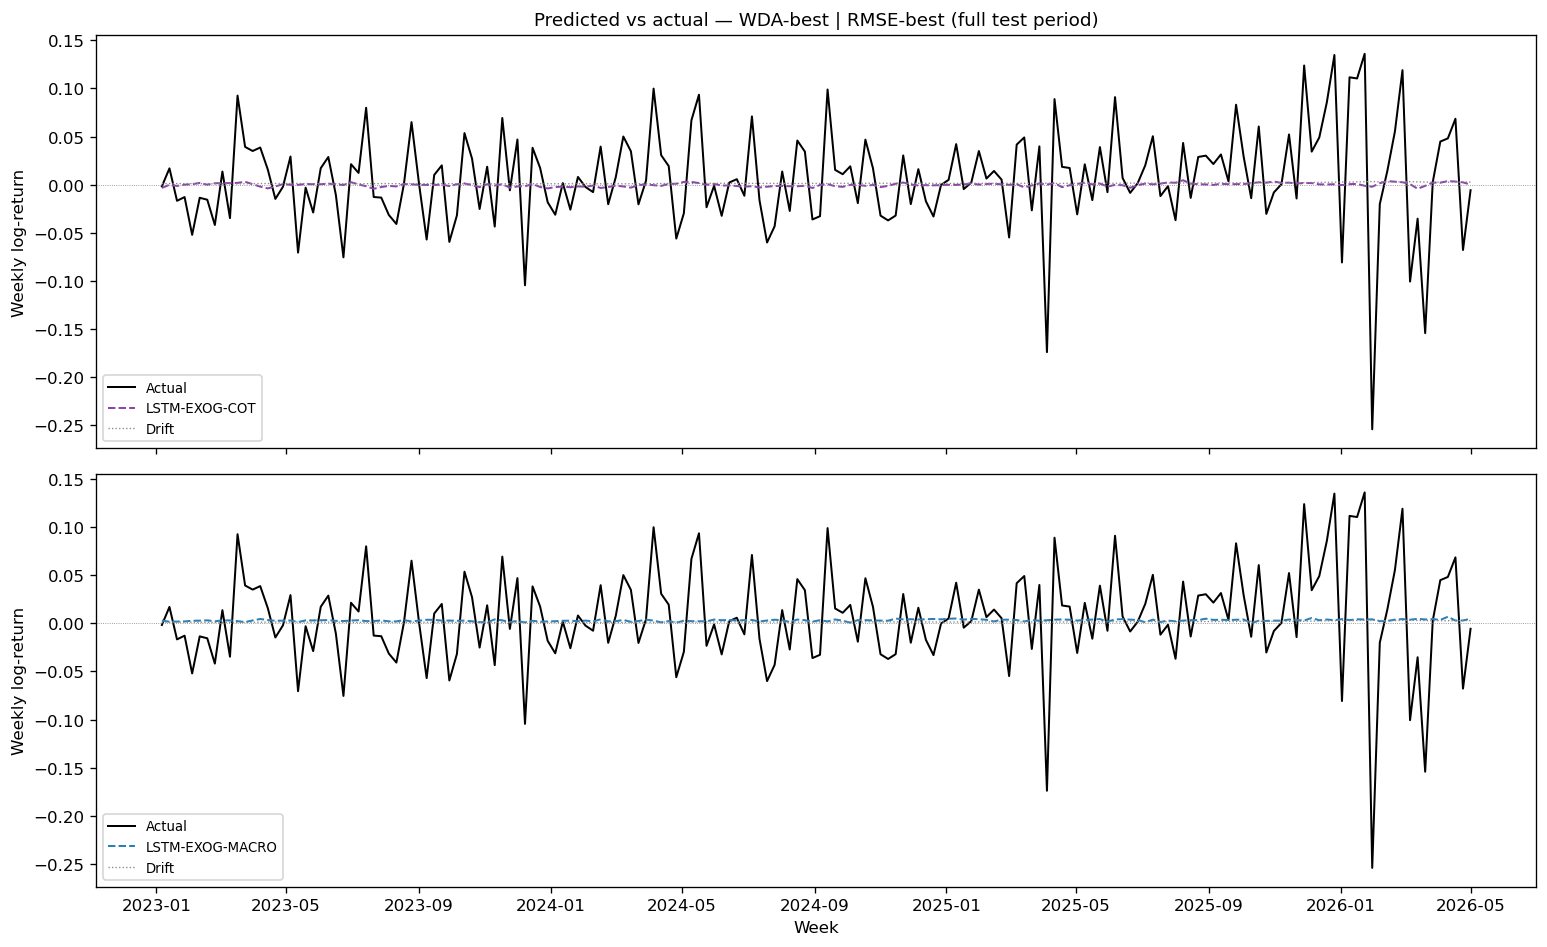

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

_idx   = pd.DatetimeIndex(dates_arr)
_act   = pd.Series(actuals_arr,  index=_idx)
_drift = pd.Series(drift_pred,   index=_idx)
_wda   = pd.Series(best_pred,    index=_idx)
_rmse  = pd.Series(best_pred_rmse, index=_idx)

for ax, pred_s, label, color in [
    (axes[0], _wda,  best_name,      '#8e44ad'),
    (axes[1], _rmse, best_name_rmse, '#2980b9'),
]:
    ax.plot(_idx, _act,   color='black',  lw=1.2, label='Actual')
    ax.plot(_idx, pred_s, color=color,    lw=1.2, ls='--', label=label)
    ax.plot(_idx, _drift, color='#888',   lw=0.8, ls=':',  label='Drift')
    ax.axhline(0, color='grey', lw=0.5, ls=':')
    ax.set_ylabel('Weekly log-return')
    ax.legend(fontsize=8)

axes[0].set_title('Predicted vs actual — WDA-best | RMSE-best (full test period)', fontsize=11)
axes[1].set_xlabel('Week')
plt.tight_layout()
plt.show()


## 9. Significance tests

### DM — squared-error floor (load-bearing)

The headline test: does any variant produce significantly lower **squared** forecast errors than
the Drift? This is the proper significance test for the OOS R² in §6 (both MSFE-based).

In [15]:
# Semi-strong floor [PRIMARY] — squared-error loss vs Drift.
# DM is the significance test for the OOS R^2 in §6 (both MSFE-based).
print("Diebold-Mariano -- vs Drift floor   [squared error]")
print("Semi-strong test: can any variant beat the no-predictability drift?")
print("-" * 90)
for name, pred in all_preds.items():
    diebold_mariano(actuals_arr, drift_pred, pred, "Drift", name)

Diebold-Mariano -- vs Drift floor   [squared error]
Semi-strong test: can any variant beat the no-predictability drift?
------------------------------------------------------------------------------------------
Drift                                    vs LSTM-Y                                    DM=+0.607  p=0.544  (ns)  -> winner: tie
Drift                                    vs LSTM-TECH                                 DM=-0.806  p=0.420  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG                                 DM=-0.912  p=0.362  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG-GS                              DM=+0.005  p=0.996  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG-NONLIN                          DM=-1.074  p=0.283  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG-TECH                            DM=-2.830  p=0.005  **    -> winner: Drift
Drift                    

### DM — absolute-error (robustness)

Same framework, loss $\lvert y-\hat y\rvert$ instead of $(y-\hat y)^2$. Weekly silver returns
are heavy-tailed — a few outlier weeks dominate squared loss. Absolute-error checks whether
the result survives a less outlier-sensitive criterion. Squared error stays the headline.

In [16]:
# Robustness -- floor test under ABSOLUTE-error loss.
print("Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]")
print("-" * 90)
for name, pred in all_preds.items():
    diebold_mariano(actuals_arr, drift_pred, pred, "Drift", name, loss='ae')

Diebold-Mariano -- vs Drift floor   [absolute-error loss, robustness]
------------------------------------------------------------------------------------------
Drift                                    vs LSTM-Y                                    DM=+0.333  p=0.739  (ns)  -> winner: tie
Drift                                    vs LSTM-TECH                                 DM=-1.764  p=0.078  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG                                 DM=-2.030  p=0.042  *     -> winner: Drift
Drift                                    vs LSTM-EXOG-GS                              DM=+0.031  p=0.975  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG-NONLIN                          DM=-0.715  p=0.474  (ns)  -> winner: tie
Drift                                    vs LSTM-EXOG-TECH                            DM=-2.347  p=0.019  *     -> winner: Drift
Drift                                    vs LSTM-EXOG-MACRO              

## 9b. Directional test — Pesaran–Timmermann (secondary lens)

In [17]:
from eval_utils import pesaran_timmermann

print("Pesaran-Timmermann directional test — full test window")
print("H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001")
print("-" * 90)
pesaran_timmermann(actuals_arr, drift_pred, name="Drift (always-up)")   # degenerate ref
pt_results = {n: pesaran_timmermann(actuals_arr, p, name=n) for n, p in all_preds.items()}
_tested = [r for r in pt_results.values() if not np.isnan(r['p'])]
_sig    = {n: r for n, r in pt_results.items() if not np.isnan(r['p']) and r['p'] < 0.05}
print(f"\n{len(_sig)}/{len(_tested)} variants significant at p<0.05 "
      f"(~{0.05 * len(_tested):.1f} expected by chance): {list(_sig)}")

print(f"\nPer-period PT — {best_name}:")
_yt = pd.Series(actuals_arr, index=pd.DatetimeIndex(dates_arr))
_bp = pd.Series(best_pred, index=pd.DatetimeIndex(dates_arr))
for _lbl, (_a, _b) in PERIODS.items():
    _yy = _yt.loc[_a:_b].values
    _pp = _bp.loc[_a:_b].values
    if len(_yy) >= 12:
        pesaran_timmermann(_yy, _pp, name=f"  {_lbl}  (n={len(_yy)})")

Pesaran-Timmermann directional test — full test window
H0: predicted & actual signs independent  |  * p<0.05  ** p<0.01  *** p<0.001
------------------------------------------------------------------------------------------
Drift (always-up)                         DA=0.557  DA|indep=0.557  PT degenerate (constant-sign forecast)  -> winner: n/a
LSTM-Y                                    DA=0.552  DA|indep=0.541  PT=+0.409  p=0.683  (ns)  -> winner: tie (chance)
LSTM-TECH                                 DA=0.477  DA|indep=0.520  PT=-1.239  p=0.215  (ns)  -> winner: tie (chance)
LSTM-EXOG                                 DA=0.443  DA|indep=0.462  PT=-0.699  p=0.485  (ns)  -> winner: tie (chance)
LSTM-EXOG-GS                              DA=0.609  DA|indep=0.516  PT=+2.586  p=0.010  **    -> winner: LSTM-EXOG-GS
LSTM-EXOG-NONLIN                          DA=0.552  DA|indep=0.524  PT=+0.818  p=0.414  (ns)  -> winner: tie (chance)
LSTM-EXOG-TECH                            DA=0.443  DA|indep=0.

## 9c. Robustness — drop the 2025 bull run (full battery)

2025 carries the entire always-up directional line, so once the full-window tests are done,
re-run **the whole battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026**
only. Evaluation-only (models unchanged); pooled (per-year DM is underpowered). The efficiency
conclusion *strengthens* once the bull is removed.

In [18]:
from eval_utils import pesaran_timmermann
# Full battery on the non-bull window — evaluation only, forecasts unchanged.
mask_ex25 = np.array(pd.DatetimeIndex(dates_arr).year != 2025)
a_ex      = actuals_arr[mask_ex25]
drift_ex  = drift_pred[mask_ex25]
dates_ex  = pd.DatetimeIndex(dates_arr)[mask_ex25]
_preds_ex = {name: np.asarray(pred)[mask_ex25] for name, pred in all_preds.items()}
au_ex     = np.sum(np.abs(a_ex) * (a_ex > 0)) / np.sum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  always-up WDA = {au_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
from sklearn.metrics import mean_squared_error, mean_absolute_error
for name, pred_ex in _preds_ex.items():
    rmse = np.sqrt(mean_squared_error(a_ex, pred_ex))
    mae  = mean_absolute_error(a_ex, pred_ex)
    da   = np.mean(np.sign(a_ex) == np.sign(pred_ex))
    wda  = np.sum(np.abs(a_ex) * (np.sign(a_ex) == np.sign(pred_ex))) / np.sum(np.abs(a_ex))
    print(f'{name:<35}  RMSE={rmse:.5f}  MAE={mae:.5f}  DA={da:.3f}  WDA={wda:.3f}')

print('\nOOS R^2 vs Drift (2025 excluded):')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    _r2 = oos_r2(a_ex, pred_ex, drift_ex) * 100
    print(f'  {name:35s} R2_OS = {_r2:+6.2f}%   -> winner: {name if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    diebold_mariano(a_ex, drift_ex, pred_ex, 'Drift', name)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    diebold_mariano(a_ex, drift_ex, pred_ex, 'Drift', name, loss='ae')

print('\nPesaran-Timmermann (2025 excluded):')
print('-' * 90)
for name, pred_ex in _preds_ex.items():
    pesaran_timmermann(a_ex, pred_ex, name=name)


Ex-2025 sample: 122 weeks  |  always-up WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
LSTM-Y                               RMSE=0.05251  MAE=0.03787  DA=0.525  WDA=0.580
LSTM-TECH                            RMSE=0.05293  MAE=0.03839  DA=0.467  WDA=0.446
LSTM-EXOG                            RMSE=0.05273  MAE=0.03818  DA=0.467  WDA=0.509
LSTM-EXOG-GS                         RMSE=0.05213  MAE=0.03749  DA=0.631  WDA=0.673
LSTM-EXOG-NONLIN                     RMSE=0.05270  MAE=0.03778  DA=0.549  WDA=0.541
LSTM-EXOG-TECH                       RMSE=0.05303  MAE=0.03811  DA=0.484  WDA=0.462
LSTM-EXOG-MACRO                      RMSE=0.05269  MAE=0.03800  DA=0.500  WDA=0.520
LSTM-EXOG-FRED                       RMSE=0.05281  MAE=0.03800  DA=0.475  WDA=0.460
LSTM-EXOG-COT                        RMSE=0.05232  MAE=0.03752  DA=0.582  WDA=0.661
LSTM-EXOG-FRED-COT                   RMSE=0.05259  MAE=0.03765  DA=0.590  WDA=0.582
LSTM-EXOG-REDDIT                     RMSE=0.05311  MAE=0.

## 10. 2026 zoom — actual vs best variants

Most recent out-of-sample slice, where silver has been most active. Two panels: WDA-best
(directional pick) and RMSE-best (magnitude pick), each with the Drift floor overlaid.

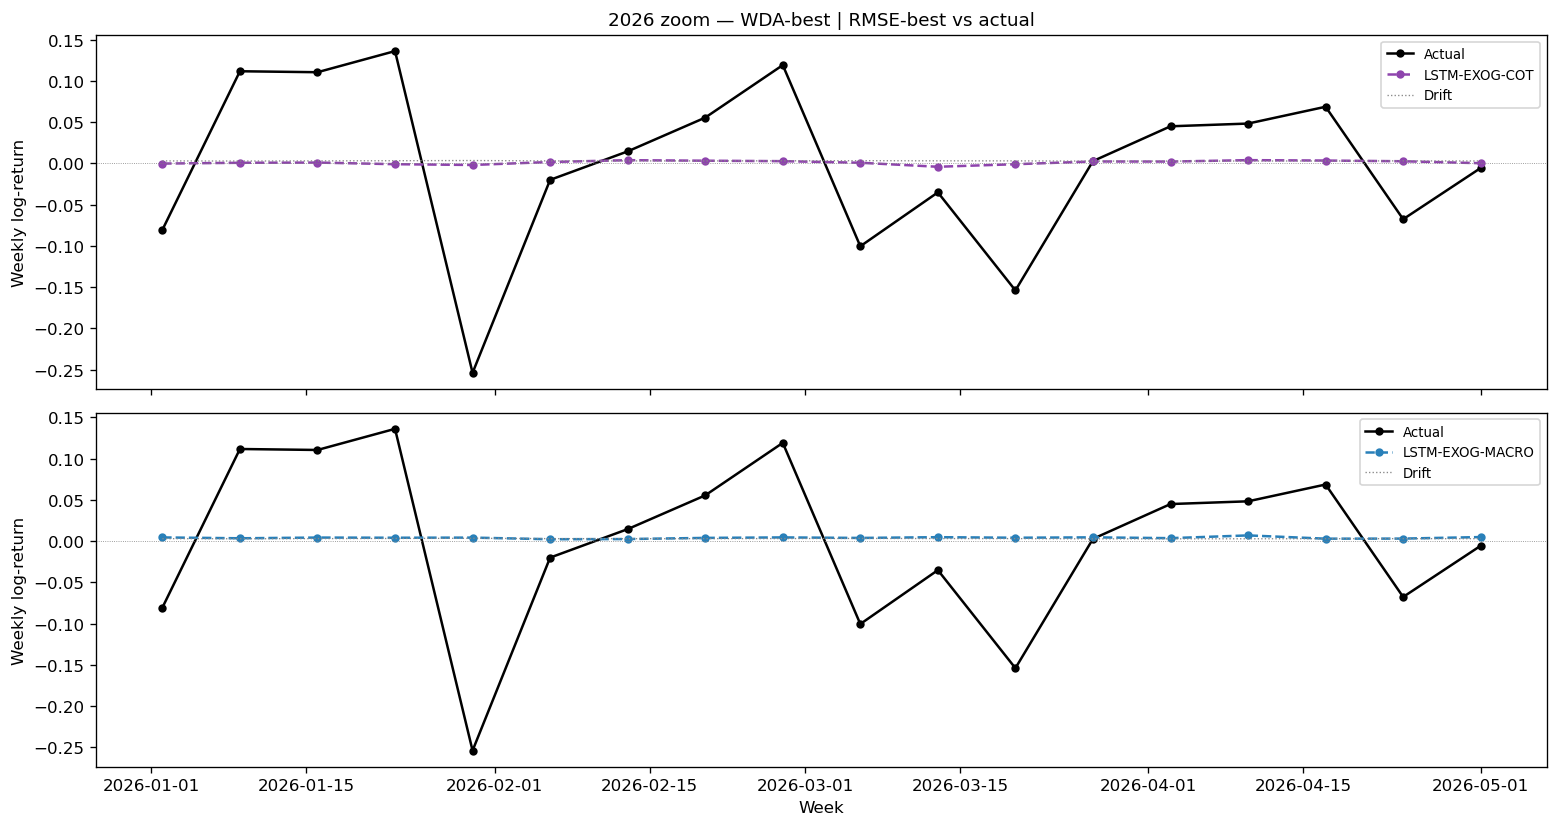

In [19]:
_idx26  = pd.DatetimeIndex(dates_arr)
_mask26 = _idx26.year == 2026

if _mask26.sum() == 0:
    print('No 2026 data in test set yet.')
else:
    _act26   = actuals_arr[_mask26]
    _drift26 = drift_pred[_mask26]
    _wda26   = best_pred[_mask26]
    _rmse26  = best_pred_rmse[_mask26]
    _dates26 = _idx26[_mask26]

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ax, pred26, label, color in [
        (axes[0], _wda26,  best_name,      '#8e44ad'),
        (axes[1], _rmse26, best_name_rmse, '#2980b9'),
    ]:
        ax.plot(_dates26, _act26,   color='black', lw=1.5, marker='o', ms=4, label='Actual')
        ax.plot(_dates26, pred26,   color=color,   lw=1.5, marker='o', ms=4, ls='--', label=label)
        ax.plot(_dates26, _drift26, color='#888',  lw=0.8, ls=':',               label='Drift')
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.set_ylabel('Weekly log-return')
        ax.legend(fontsize=8)

    axes[0].set_title('2026 zoom — WDA-best | RMSE-best vs actual', fontsize=11)
    axes[1].set_xlabel('Week')
    plt.tight_layout()
    plt.show()


In [20]:
  # TODO (later): seed-robustness for the headline LSTM numbers — they're a single random
  # draw (weight init + batch shuffle + MPS nondeterminism), so report mean±std over 3–5 seeds
  # to defend the null against a "lucky seed" critique. Minimal/additive:
  #   1. add seed=None to run_variant(): if set, torch.manual_seed(seed); np.random.seed(seed)
  #      and tag the ckpt path with the seed so §5's headline checkpoints aren't clobbered.
  #   2. new cell after §9: SEEDS=[42,1,2,3,4], loop over {LSTM-EXOG, LSTM-EXOG-ALL, best_name}
  #      ONLY (not all 17); print mean±std RMSE/WDA/OOS-R² + #seeds with R²_OS>0 vs drift.